In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

c:\Projects\Code-Mixed-Hate-Speech-Detection-in-Sinhala-Tamil-English\hate_speech_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Load Splits
train_df = pd.read_csv("../data/processed/train.csv")
val_df   = pd.read_csv("../data/processed/val.csv")
test_df  = pd.read_csv("../data/processed/test.csv")

X_train = train_df["Comment_clean"].tolist()
y_train = train_df["Label_id"]

X_val = val_df["Comment_clean"].tolist()
y_val = val_df["Label_id"]

X_test = test_df["Comment_clean"].tolist()
y_test = test_df["Label_id"]


In [4]:
#Load Multilingual Embedding Model
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 396.99it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
#Generate Embeddings (Batch-wise)
X_train_emb = model.encode(X_train, batch_size=64, show_progress_bar=True)
X_val_emb   = model.encode(X_val, batch_size=64, show_progress_bar=True)
X_test_emb  = model.encode(X_test, batch_size=64, show_progress_bar=True)



Batches: 100%|██████████| 112/112 [01:30<00:00,  1.23it/s]


In [8]:
#Save Embeddings
np.save("../models/train_embeddings.npy", X_train_emb)
np.save("../models/val_embeddings.npy", X_val_emb)
np.save("../models/test_embeddings.npy", X_test_emb)


In [9]:
#Train Cost-Sensitive SVM (RBF Kernel)
svm = LinearSVC(
    class_weight="balanced",
    max_iter=2000,
    C=0.01,                     
    loss='squared_hinge'
)

svm.fit(X_train_emb, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.01
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseu

In [10]:
#Evaluate
y_test_pred = svm.predict(X_test_emb)

print("Hybrid Model (Embeddings + Linear SVM Balanced)")
print(classification_report(y_test, y_test_pred, target_names=["NON_HATE", "HATE"]))



Hybrid Model (Embeddings + Linear SVM Balanced)
              precision    recall  f1-score   support

    NON_HATE       0.92      0.68      0.78      5673
        HATE       0.38      0.77      0.51      1458

    accuracy                           0.70      7131
   macro avg       0.65      0.73      0.65      7131
weighted avg       0.81      0.70      0.73      7131



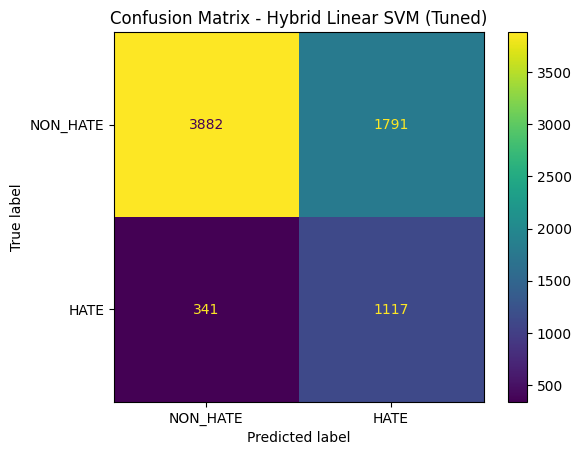

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NON_HATE", "HATE"]
)

disp.plot()
plt.title("Confusion Matrix - Hybrid Linear SVM (Tuned)")
plt.savefig("../results/hybrid_linear_tuned_confusion_matrix.png")
plt.show()



In [12]:
# Save model & embeddings
joblib.dump(svm, "../models/tier2_svm.pkl")

print("Tier 2 model saved.")


Tier 2 model saved.


In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score


report_text = classification_report(
    y_test,
    y_test_pred,
    target_names=["NON_HATE", "HATE"]
)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

with open("../results/hybrid_linear_tuned_results.txt", "w", encoding="utf-8") as f:
    f.write("=== Hybrid Model (Embeddings + Linear SVM Balanced Tuned) ===\n\n")
    f.write(report_text)
    f.write("Accuracy: {:.4f}\n".format(accuracy))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))



In [14]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [accuracy, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.ylim(0, 1)
plt.title("Hybrid Model (Embeddings + Linear SVM Balanced Tuned)")
plt.savefig("../results/plots/hybrid_linear_tuned_metrics.png")
plt.close()

print("Metric plot saved.")

Metric plot saved.
